In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Project Started Successfully!")

Project Started Successfully!


In [ ]:
np.random.seed(42)
n = 1000

In [ ]:
data = pd.DataFrame({
    "Attendance": np.random.randint(40, 101, n),
    "Study_Hours": np.round(np.random.uniform(1, 10, n), 1),
    "Previous_Marks": np.random.randint(35, 96, n),
    "Assignment_Score": np.random.randint(30, 101, n),
    "Internal_Marks": np.random.randint(30, 96, n),
    "Backlogs": np.random.randint(0, 5, n),
    "Family_Income": np.random.randint(10000, 100001, n)
})


In [ ]:
risk_score = (
    (100 - data["Attendance"]) * 0.30 +
    (10 - data["Study_Hours"]) * 3 +
    (100 - data["Previous_Marks"]) * 0.25 +
    (100 - data["Assignment_Score"]) * 0.15 +
    (100 - data["Internal_Marks"]) * 0.15 +
    data["Backlogs"] * 5
)

In [ ]:
data["Dropout_Risk"] = (risk_score > 50).astype(int)

In [ ]:
print("Dataset created successfully!")
print("Total Students:", len(data))


Dataset created successfully!
Total Students: 1000


In [ ]:
data.head()

,Attendance,Study_Hours,Previous_Marks,Assignment_Score,Internal_Marks,Backlogs,Family_Income,Dropout_Risk
0,78,9.5,59,68,54,1,19130,0
1,91,8.6,64,69,50,1,99360,0
2,68,3.2,45,67,94,1,72287,1
3,54,5.1,41,89,92,0,61702,0
4,82,2.2,65,88,80,4,46993,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Attendance        1000 non-null   int64  
 1   Study_Hours       1000 non-null   float64
 2   Previous_Marks    1000 non-null   int64  
 3   Assignment_Score  1000 non-null   int64  
 4   Internal_Marks    1000 non-null   int64  
 5   Backlogs          1000 non-null   int64  
 6   Family_Income     1000 non-null   int64  
 7   Dropout_Risk      1000 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 62.6 KB


In [ ]:
data.describe()

,Attendance,Study_Hours,Previous_Marks,Assignment_Score,Internal_Marks,Backlogs,Family_Income,Dropout_Risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,70.879000,5.452300,64.727000,65.134000,63.917000,2.04700,55309.880000,0.560000
std,17.637558,2.610603,17.597276,19.935432,19.365256,1.39382,26453.769263,0.496635
min,40.000000,1.000000,35.000000,30.000000,30.000000,0.00000,10060.000000,0.000000
25%,56.000000,3.100000,50.000000,48.000000,47.000000,1.00000,32963.500000,0.000000
50%,71.000000,5.500000,64.500000,65.000000,64.500000,2.00000,54189.500000,1.000000
75%,87.000000,7.625000,80.000000,82.000000,82.000000,3.00000,78635.500000,1.000000
max,100.000000,10.000000,95.000000,100.000000,95.000000,4.00000,99962.000000,1.000000


In [ ]:
data.isnull().sum()

,0
Attendance,0
Study_Hours,0
Previous_Marks,0
Assignment_Score,0
Internal_Marks,0
Backlogs,0
Family_Income,0
Dropout_Risk,0


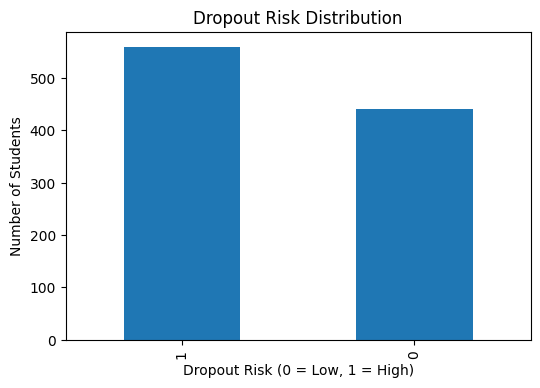

In [ ]:
data["Dropout_Risk"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Dropout Risk Distribution")
plt.xlabel("Dropout Risk (0 = Low, 1 = High)")
plt.ylabel("Number of Students")
plt.show()

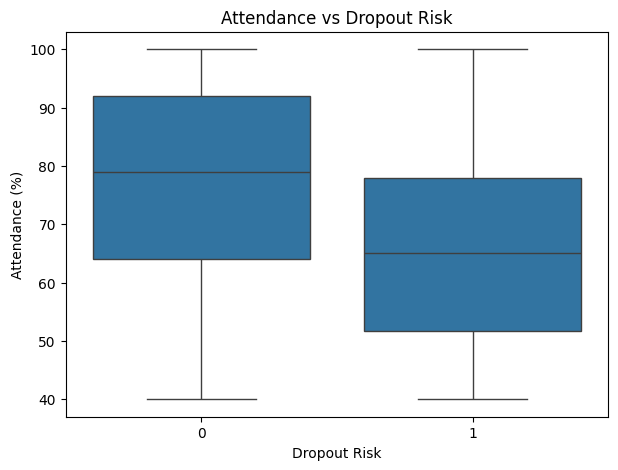

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Dropout_Risk",
    y="Attendance",
    data=data
)
plt.title("Attendance vs Dropout Risk")
plt.xlabel("Dropout Risk")
plt.ylabel("Attendance (%)")
plt.show()

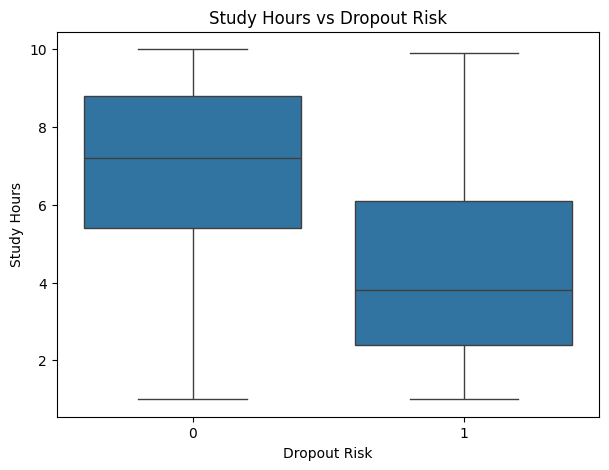

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Dropout_Risk",
    y="Study_Hours",
    data=data
)

plt.title("Study Hours vs Dropout Risk")
plt.xlabel("Dropout Risk")
plt.ylabel("Study Hours")
plt.show()

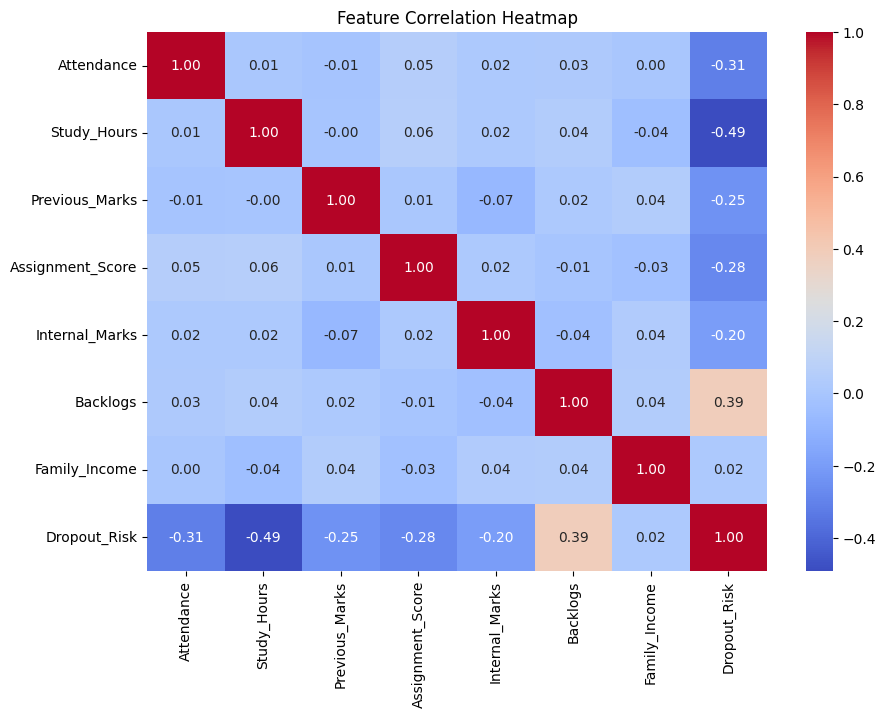

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
X = data.drop("Dropout_Risk", axis=1)
y = data["Dropout_Risk"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Attendance', 'Study_Hours', 'Previous_Marks', 'Assignment_Score',
       'Internal_Marks', 'Backlogs', 'Family_Income'],
      dtype='object')

Target:
Dropout_Risk


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 7)
Testing Data: (200, 7)


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

logistic_prediction = logistic_model.predict(X_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

Logistic Regression Accuracy: 0.99


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print("Random Forest Accuracy:",
      rf_accuracy)

Random Forest Accuracy: 0.91


In [ ]:
print("Model Performance")
print("-------------------------")
print("Logistic Regression:", logistic_accuracy)
print("Random Forest:", rf_accuracy)

Model Performance
-------------------------
Logistic Regression: 0.99
Random Forest: 0.91


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("LOGISTIC REGRESSION")
print("-------------------------")
print("Accuracy :", accuracy_score(y_test, logistic_prediction))
print("Precision:", precision_score(y_test, logistic_prediction))
print("Recall   :", recall_score(y_test, logistic_prediction))
print("F1 Score :", f1_score(y_test, logistic_prediction))

print("\nClassification Report:")
print(classification_report(y_test, logistic_prediction))

LOGISTIC REGRESSION
-------------------------
Accuracy : 0.99
Precision: 0.9910714285714286
Recall   : 0.9910714285714286
F1 Score : 0.9910714285714286

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        88
           1       0.99      0.99      0.99       112

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



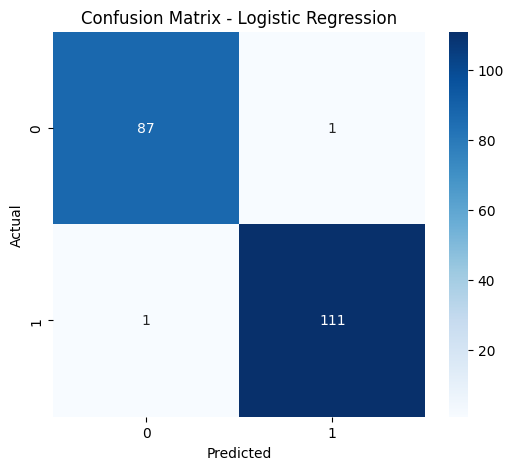

In [ ]:
cm = confusion_matrix(y_test, logistic_prediction)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

            Feature  Importance
1       Study_Hours    0.278639
0        Attendance    0.154420
5          Backlogs    0.150644
2    Previous_Marks    0.129355
3  Assignment_Score    0.117600
4    Internal_Marks    0.101927
6     Family_Income    0.067416


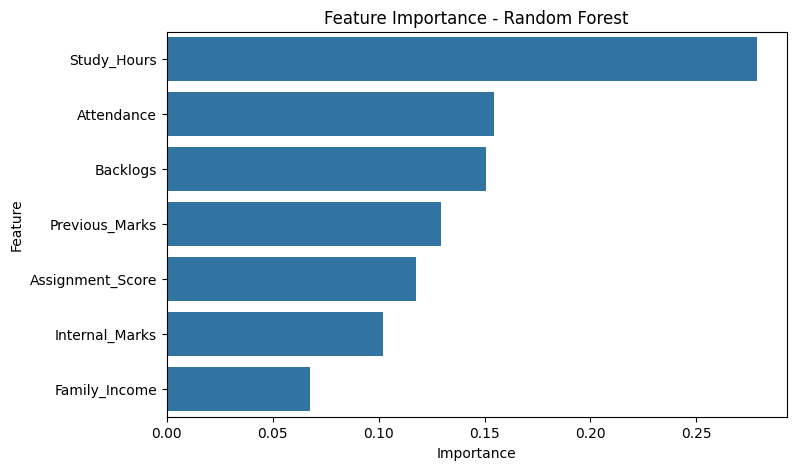

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_prediction = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_prediction
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.93


In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

print(model_results)

                 Model  Accuracy
0  Logistic Regression      0.99
1        Random Forest      0.91
2              XGBoost      0.93


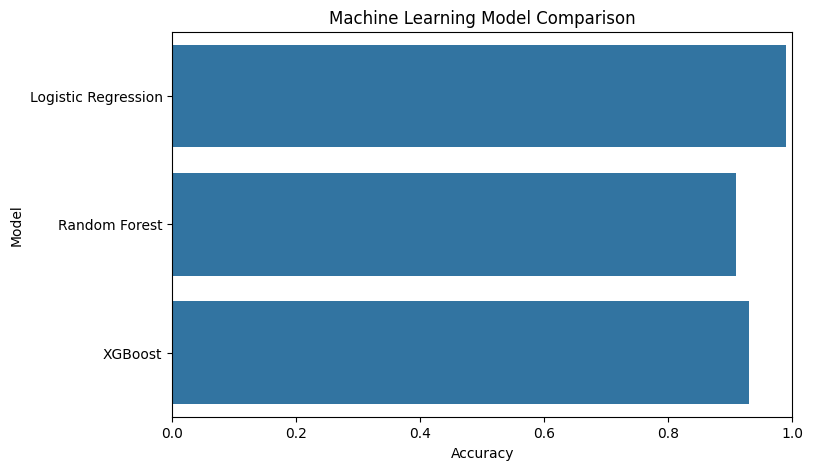

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=model_results
)

plt.xlim(0, 1)
plt.title("Machine Learning Model Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": logistic_prediction,
    "Random Forest": rf_prediction,
    "XGBoost": xgb_prediction
}

for name, prediction in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction)
    })

results_df = pd.DataFrame(results)

print(results_df.round(3))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression      0.99      0.991   0.991     0.991
1        Random Forest      0.91      0.927   0.911     0.919
2              XGBoost      0.93      0.954   0.920     0.936


In [ ]:
!pip install ucimlrepo -q

In [ ]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=697)

X_real = dataset.data.features
y_real = dataset.data.targets

print("Dataset loaded successfully!")
print("Features:", X_real.shape)
print("Target:", y_real.shape)

Dataset loaded successfully!
Features: (4424, 36)
Target: (4424, 1)


In [ ]:
print(X_real.head())

   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                           122.0     

In [ ]:
print(y_real.head())

     Target
0   Dropout
1  Graduate
2   Dropout
3  Graduate
4  Graduate


In [ ]:
print(y_real.value_counts())

Target  
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [ ]:
print(y_real.columns)

Index(['Target'], dtype='object')


In [ ]:
y_real = y_real.iloc[:, 0]

In [ ]:
print("\nTarget values:")
print(y_real.value_counts())


Target values:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [ ]:
missing_values = X_real.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

print("\nTotal missing values:",
      X_real.isnull().sum().sum())

Missing values in each column:
Series([], dtype: int64)

Total missing values: 0


In [ ]:
print("Dataset Shape:", X_real.shape)

print("\nData Types:")
print(X_real.dtypes)

print("\nFirst 5 rows:")
display(X_real.head())

Dataset Shape: (4424, 36)

Data Types:
Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date          

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [ ]:
print("Total Features:", len(X_real.columns))

print("\nFeature Names:")
for i, col in enumerate(X_real.columns, 1):
    print(i, col)

Total Features: 36

Feature Names:
1 Marital Status
2 Application mode
3 Application order
4 Course
5 Daytime/evening attendance
6 Previous qualification
7 Previous qualification (grade)
8 Nacionality
9 Mother's qualification
10 Father's qualification
11 Mother's occupation
12 Father's occupation
13 Admission grade
14 Displaced
15 Educational special needs
16 Debtor
17 Tuition fees up to date
18 Gender
19 Scholarship holder
20 Age at enrollment
21 International
22 Curricular units 1st sem (credited)
23 Curricular units 1st sem (enrolled)
24 Curricular units 1st sem (evaluations)
25 Curricular units 1st sem (approved)
26 Curricular units 1st sem (grade)
27 Curricular units 1st sem (without evaluations)
28 Curricular units 2nd sem (credited)
29 Curricular units 2nd sem (enrolled)
30 Curricular units 2nd sem (evaluations)
31 Curricular units 2nd sem (approved)
32 Curricular units 2nd sem (grade)
33 Curricular units 2nd sem (without evaluations)
34 Unemployment rate
35 Inflation rate
36 GD

In [ ]:
print(X_real.dtypes.value_counts())

int64      29
float64     7
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
categorical_features = [
    "Marital Status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]
numerical_features = [
    col for col in X_real.columns
    if col not in categorical_features
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

print("\nNumerical features:")
print(numerical_features)

Categorical features: 18
Numerical features: 18

Numerical features:
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [ ]:
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    random_state=42,
    stratify=y_real
)

print("Training samples:", len(X_train_real))
print("Testing samples:", len(X_test_real))

Training samples: 3539
Testing samples: 885


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])


logistic_pipeline.fit(
    X_train_real,
    y_train_real
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
logistic_real_pred = logistic_pipeline.predict(X_test_real)

print("Prediction completed!")
print("First 20 predictions:")
print(logistic_real_pred[:20])

Prediction completed!
First 20 predictions:
['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate' 'Dropout'
 'Graduate' 'Graduate' 'Graduate' 'Graduate' 'Graduate' 'Enrolled'
 'Dropout' 'Dropout' 'Enrolled' 'Enrolled' 'Graduate' 'Dropout' 'Dropout'
 'Dropout']


In [ ]:
logistic_real_accuracy = accuracy_score(
    y_test_real,
    logistic_real_pred
)

logistic_real_precision = precision_score(
    y_test_real,
    logistic_real_pred,
    average="weighted"
)

logistic_real_recall = recall_score(
    y_test_real,
    logistic_real_pred,
    average="weighted"
)

logistic_real_f1 = f1_score(
    y_test_real,
    logistic_real_pred,
    average="weighted"
)

print("LOGISTIC REGRESSION - REAL DATASET")
print("-----------------------------------")
print("Accuracy :", round(logistic_real_accuracy, 4))
print("Precision:", round(logistic_real_precision, 4))
print("Recall   :", round(logistic_real_recall, 4))
print("F1 Score :", round(logistic_real_f1, 4))

LOGISTIC REGRESSION - REAL DATASET
-----------------------------------
Accuracy : 0.7684
Precision: 0.7552
Recall   : 0.7684
F1 Score : 0.7577


In [ ]:
print("\nClassification Report:")
print(
    classification_report(
        y_test_real,
        logistic_real_pred
    )
)


Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.55      0.40      0.46       159
    Graduate       0.81      0.91      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



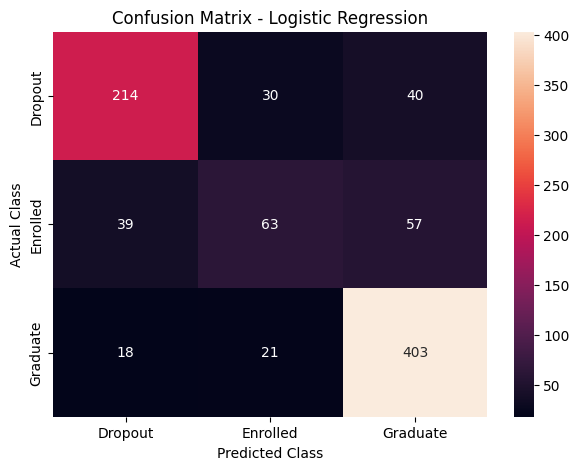

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test_real,
    logistic_real_pred,
    labels=["Dropout", "Enrolled", "Graduate"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Dropout", "Enrolled", "Graduate"],
    yticklabels=["Dropout", "Enrolled", "Graduate"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])


rf_pipeline.fit(
    X_train_real,
    y_train_real
)


rf_real_pred = rf_pipeline.predict(X_test_real)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
rf_real_accuracy = accuracy_score(
    y_test_real,
    rf_real_pred
)

rf_real_precision = precision_score(
    y_test_real,
    rf_real_pred,
    average="weighted"
)

rf_real_recall = recall_score(
    y_test_real,
    rf_real_pred,
    average="weighted"
)

rf_real_f1 = f1_score(
    y_test_real,
    rf_real_pred,
    average="weighted"
)

print("RANDOM FOREST - REAL DATASET")
print("--------------------------------")
print("Accuracy :", round(rf_real_accuracy, 4))
print("Precision:", round(rf_real_precision, 4))
print("Recall   :", round(rf_real_recall, 4))
print("F1 Score :", round(rf_real_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_real,
    rf_real_pred
))

RANDOM FOREST - REAL DATASET
--------------------------------
Accuracy : 0.765
Precision: 0.7459
Recall   : 0.765
F1 Score : 0.7446

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       284
    Enrolled       0.55      0.30      0.39       159
    Graduate       0.78      0.94      0.86       442

    accuracy                           0.76       885
   macro avg       0.71      0.66      0.67       885
weighted avg       0.75      0.76      0.74       885



In [ ]:
from xgboost import XGBClassifier


target_mapping = {
    "Dropout": 0,
    "Enrolled": 1,
    "Graduate": 2
}

y_train_xgb = y_train_real.map(target_mapping)
y_test_xgb = y_test_real.map(target_mapping)


xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="mlogloss"
    ))
])


xgb_pipeline.fit(
    X_train_real,
    y_train_xgb
)


xgb_real_pred_num = xgb_pipeline.predict(X_test_real)


reverse_mapping = {
    0: "Dropout",
    1: "Enrolled",
    2: "Graduate"
}

xgb_real_pred = pd.Series(
    xgb_real_pred_num
).map(reverse_mapping)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [ ]:
xgb_real_accuracy = accuracy_score(
    y_test_real,
    xgb_real_pred
)

xgb_real_precision = precision_score(
    y_test_real,
    xgb_real_pred,
    average="weighted"
)

xgb_real_recall = recall_score(
    y_test_real,
    xgb_real_pred,
    average="weighted"
)

xgb_real_f1 = f1_score(
    y_test_real,
    xgb_real_pred,
    average="weighted"
)

print("XGBOOST - REAL DATASET")
print("--------------------------------")
print("Accuracy :", round(xgb_real_accuracy, 4))
print("Precision:", round(xgb_real_precision, 4))
print("Recall   :", round(xgb_real_recall, 4))
print("F1 Score :", round(xgb_real_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_real,
    xgb_real_pred
))

XGBOOST - REAL DATASET
--------------------------------
Accuracy : 0.765
Precision: 0.7507
Recall   : 0.765
F1 Score : 0.7531

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.73      0.75       284
    Enrolled       0.54      0.38      0.45       159
    Graduate       0.81      0.93      0.86       442

    accuracy                           0.76       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



In [ ]:
real_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_real_accuracy,
        rf_real_accuracy,
        xgb_real_accuracy
    ],
    "Precision": [
        logistic_real_precision,
        rf_real_precision,
        xgb_real_precision
    ],
    "Recall": [
        logistic_real_recall,
        rf_real_recall,
        xgb_real_recall
    ],
    "F1 Score": [
        logistic_real_f1,
        rf_real_f1,
        xgb_real_f1
    ]
})

print(real_results.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.7684     0.7552  0.7684    0.7577
1        Random Forest    0.7650     0.7459  0.7650    0.7446
2              XGBoost    0.7650     0.7507  0.7650    0.7531


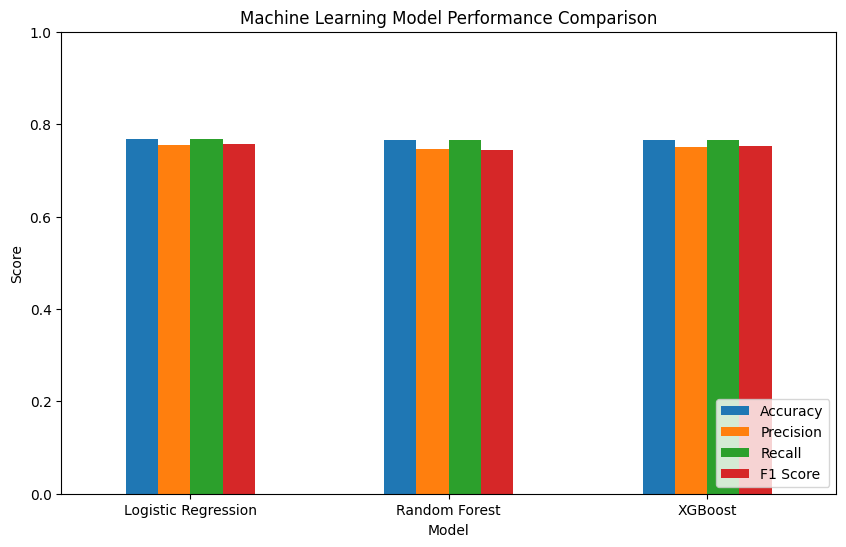

In [ ]:
real_results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

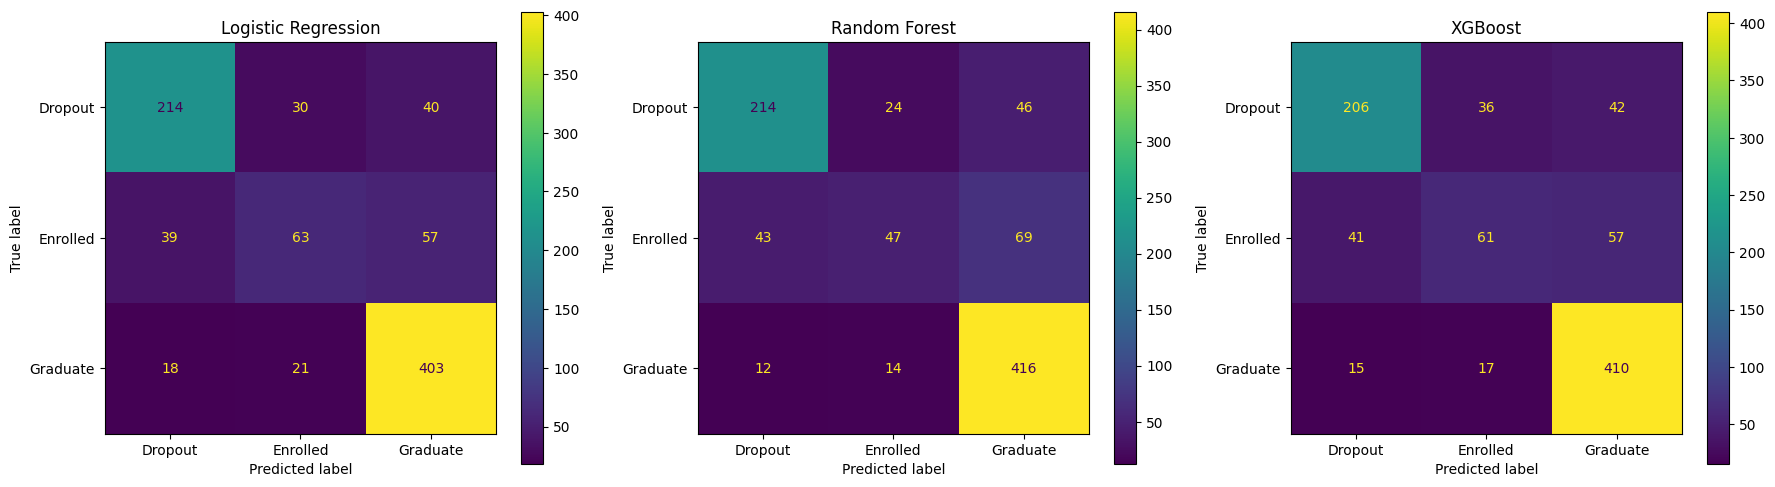

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_real,
    logistic_real_pred,
    labels=["Dropout", "Enrolled", "Graduate"],
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test_real,
    rf_real_pred,
    labels=["Dropout", "Enrolled", "Graduate"],
    ax=axes[1]
)
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(
    y_test_real,
    xgb_real_pred,
    labels=["Dropout", "Enrolled", "Graduate"],
    ax=axes[2]
)
axes[2].set_title("XGBoost")

plt.tight_layout()
plt.show()

In [ ]:
import joblib


joblib.dump(
    logistic_pipeline,
    "student_prediction_model.pkl"
)


joblib.dump(
    list(X_real.columns),
    "feature_names.pkl"
)

print("Model saved successfully!")
print("Files created:")
print("1. student_prediction_model.pkl")
print("2. feature_names.pkl")

Model saved successfully!
Files created:
1. student_prediction_model.pkl
2. feature_names.pkl


In [ ]:

loaded_model = joblib.load(
    "student_prediction_model.pkl"
)


sample_student = X_test_real.iloc[[0]]

prediction = loaded_model.predict(sample_student)

print("Predicted Result:", prediction[0])
print("Actual Result:", y_test_real.iloc[0])

Predicted Result: Graduate
Actual Result: Graduate


In [ ]:
!pip install flask -q

In [ ]:
from flask import Flask, render_template, request
import joblib

app = Flask(__name__)


model = joblib.load("student_prediction_model.pkl")


@app.route("/")
def home():
    return render_template("index.html")

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [ ]:
!pip install flask -q

In [ ]:
import flask

print("Flask version:", flask.__version__)
print("Flask is ready!")

Flask version: 3.1.3
Flask is ready!


/tmp/ipykernel_2571/506643713.py:3: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print("Flask version:", flask.__version__)


In [ ]:
from flask import Flask, render_template, request
import joblib

app = Flask(__name__)

model = joblib.load("student_prediction_model.pkl")

@app.route("/")
def home():
    return "Student Prediction System is Running!"

print("Flask application created successfully!")

Flask application created successfully!


In [ ]:
import pandas as pd

class_names = {
    0: "Dropout",
    1: "Enrolled",
    2: "Graduate"
}

@app.route("/predict", methods=["POST"])
def predict():


    input_data = {}

    for feature in X_real.columns:
        value = request.form.get(feature)

        input_data[feature] = float(value)

    input_df = pd.DataFrame([input_data])

    prediction = model.predict(input_df)[0]

    probabilities = model.predict_proba(input_df)[0]
    max_probability = max(probabilities) * 100

    result = class_names.get(
        prediction,
        prediction
    )

    return f"""
    <h1>Prediction Result</h1>
    <h2>Predicted Class: {result}</h2>
    <h3>Confidence: {max_probability:.2f}%</h3>
    """

print("Prediction route created successfully!")

Prediction route created successfully!


In [ ]:
import os

os.makedirs("templates", exist_ok=True)

html_code = """
<!DOCTYPE html>
<html>
<head>
    <title>Student Prediction System</title>

    <style>
        body {
            font-family: Arial, sans-serif;
            background: #f4f6f8;
            margin: 0;
            padding: 30px;
        }

        .container {
            max-width: 1000px;
            margin: auto;
            background: white;
            padding: 30px;
            border-radius: 12px;
        }

        h1 {
            text-align: center;
            margin-bottom: 30px;
        }

        .grid {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 18px;
        }

        label {
            font-weight: bold;
            display: block;
            margin-bottom: 6px;
        }

        input {
            width: 100%;
            padding: 10px;
            box-sizing: border-box;
            border: 1px solid #ccc;
            border-radius: 6px;
        }

        .full {
            grid-column: 1 / 3;
        }

        button {
            width: 100%;
            padding: 14px;
            margin-top: 25px;
            border: none;
            border-radius: 6px;
            font-size: 17px;
            cursor: pointer;
        }
    </style>
</head>

<body>

<div class="container">

    <h1>Student Performance Prediction System</h1>

    <form action="/predict" method="POST">

        <div class="grid">

"""


for feature in X_real.columns:

    safe_name = feature.replace('"', '&quot;')

    html_code += f"""
            <div>
                <label>{feature}</label>
                <input type="number"
                       step="any"
                       name="{safe_name}"
                       required>
            </div>
"""

html_code += """

        </div>

        <button type="submit">
            Predict Student Status
        </button>

    </form>

</div>

</body>
</html>
"""

with open("templates/index.html", "w", encoding="utf-8") as file:
    file.write(html_code)

print("index.html created successfully!")
print("Total input fields:", len(X_real.columns))

index.html created successfully!
Total input fields: 36


In [ ]:
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok

ngrok.kill()

print("ngrok stopped.")

ngrok stopped.


In [ ]:
app.run(
    host="0.0.0.0",
    port=5000,
    debug=False,
    use_reloader=False
)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
from google.colab import output

url = output.eval_js(
    "google.colab.kernel.proxyPort(5000)"
)

print("Website URL:")
print(url)

Website URL:
https://5000-m-s-kkb-usw4c1-2bio31gczdmfq-c.us-west4-1.prod.colab.dev
